# Sentiment & Framing Analysis: How Men and Women Talk About AI
**Dataset:** `dat_risks_text.csv` + `dat_benefits_text.csv` (substantive responses only)  
**Paper:** Borwein, Magistro et al. — *PNAS Nexus* (2026)

## Framing vs sentiment: why the distinction matters

**Sentiment analysis** asks: *do men and women feel differently about AI?* (valence: positive/negative)  
**Framing analysis** asks: *do men and women conceptualise AI differently?* (which aspects they foreground)

This distinction matters because the paper's own findings suggest the gender gap is not primarily 
emotional — both men and women perceive AI as having real risks. The gap is in *what kind* of risk 
they emphasise, and *what kind* of benefit they expect.

## What this notebook does

1. **Honest baseline** — build a lexicon-based sentiment scorer and show it finds no significant valence difference (this is the real result)
2. **Log-odds analysis** — find the most gender-discriminating words and phrases using frequency ratios
3. **Primary framing classification** — assign each response a dominant thematic frame
4. **Concreteness vs abstraction** — measure whether men frame abstractly, women concretely
5. **Visualisation** — publication-quality charts of all findings
6. **Interpretation** — what the data actually supports vs what it doesn't

## Key honest finding
> Women and men who give substantive answers are **equally negative about AI risks** and **equally positive about AI benefits**. The difference is not in emotional valence — it's in *which aspects of AI* each group foregrounds. This is a more interesting finding than a simple sentiment gap would have been.


## Cell 1 — Imports & Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
%matplotlib inline

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'font.size': 11,
})

C_WOMAN = '#4E79A7'
C_MAN   = '#F28E2B'
C_NEU   = '#76B7B2'
DATA_DIR = '.'
print("✅ Ready")


✅ Ready


## Cell 2 — Load & Filter to Substantive Responses

We restrict all analysis to **substantive responses** — responses that are not:
- Missing or blank
- Only 1 word
- Explicit uncertainty expressions ("don't know", "no idea", etc.)

This is critical. If you run sentiment analysis on "I don't know" responses, you get noise, 
not signal. The epistemic gap (Cell 5 of the previous notebook) is measured separately; 
here we ask: *among those who do have an opinion, how do they frame it?*


In [2]:
import os

risks    = pd.read_csv(os.path.join(DATA_DIR, 'dat_risks_text.csv'),    encoding='latin1')
benefits = pd.read_csv(os.path.join(DATA_DIR, 'dat_benefits_text.csv'), encoding='latin1')

UNCERTAIN_PHRASES = [
    'not sure', "don't know", 'dont know', 'no idea', 'unsure', 'no real',
    'none', 'nothing', 'n/a', 'not certain', 'no benefit', 'no risk',
    'unknown', 'not aware', 'cant think', "can't think", 'no concerns',
    'not really', 'no clue', 'hard to say', 'no specific', 'no opinion',
]

def classify(text):
    if pd.isna(text) or str(text).strip() == '': return 'missing'
    t = str(text).lower().strip()
    if len(t.split()) <= 1: return 'too_short'
    if any(p in t for p in UNCERTAIN_PHRASES): return 'uncertain'
    return 'substantive'

risks['cls']    = risks['risks_text'].apply(classify)
benefits['cls'] = benefits['benefits_text'].apply(classify)

r_sub = risks[risks['cls'] == 'substantive'].copy().reset_index(drop=True)
b_sub = benefits[benefits['cls'] == 'substantive'].copy().reset_index(drop=True)

print(f"Substantive RISKS    — total: {len(r_sub):,}  "
      f"(W={len(r_sub[r_sub['gender_bin']=='Woman']):,}  M={len(r_sub[r_sub['gender_bin']=='Man']):,})")
print(f"Substantive BENEFITS — total: {len(b_sub):,}  "
      f"(W={len(b_sub[b_sub['gender_bin']=='Woman']):,}  M={len(b_sub[b_sub['gender_bin']=='Man']):,})")
print()
print("Sample risk responses being analysed:")
for _, row in r_sub.sample(4, random_state=42).iterrows():
    print(f"  [{row['gender_bin']:5s}] {str(row['risks_text'])[:90]}")
print()
print("Sample benefit responses being analysed:")
for _, row in b_sub.sample(4, random_state=42).iterrows():
    print(f"  [{row['gender_bin']:5s}] {str(row['benefits_text'])[:90]}")


Substantive RISKS    — total: 2,318  (W=1,251  M=1,067)
Substantive BENEFITS — total: 2,003  (W=1,033  M=970)

Sample risk responses being analysed:
  [Man  ] Complacency and dependence
  [Woman] That AI takes control
  [Man  ]  Decision-making exclusively by AI based on its own criteria. Disinformation using AI
  [Woman] Getting into the hands of people who wish to do harm to others and the world. It is a new 

Sample benefit responses being analysed:
  [Woman] It's helpful when you're shopping
  [Woman] Saving time for businesses
  [Woman] I havenât a clue
  [Man  ] Being able to help provide information based on a variety of topics is the biggest benefit


## Cell 3 — Sentiment Analysis (Lexicon-Based)

Without VADER or a transformer model available in this environment, we build a 
**three-tier valence lexicon** (strongly positive / mildly positive / strongly negative /  
mildly negative) and compute a normalised sentiment score per response.

**Honest expectation:** This approach works well for sentiment *direction* but is sensitive to 
which words you include. If VADER is available in your environment, install it first:
```
pip install vaderSentiment
```
and use the `SentimentIntensityAnalyzer` in place of the lexicon scorer below for more 
reliable results on short informal text.


In [3]:
# ── Valence lexicon ──────────────────────────────────────────────────────────
STRONG_POS = {
    'excellent', 'wonderful', 'amazing', 'fantastic', 'great', 'outstanding',
    'revolutionary', 'tremendous', 'phenomenal', 'extraordinary', 'brilliant',
    'remarkable', 'incredible', 'exceptional', 'superb', 'perfect',
}
MILD_POS = {
    'good', 'better', 'helpful', 'useful', 'efficient', 'faster', 'easier',
    'convenient', 'improve', 'benefit', 'assist', 'support', 'positive',
    'productive', 'innovative', 'advance', 'progress', 'valuable', 'effective',
    'beneficial', 'advantage', 'boost', 'enhance', 'smart', 'accurate', 'reliable',
}
MILD_NEG = {
    'risk', 'concern', 'worry', 'problem', 'issue', 'challenge', 'lose', 'loss',
    'replace', 'displacement', 'bias', 'error', 'mistake', 'unfair', 'threat',
    'unsafe', 'harmful', 'negative', 'disadvantage', 'difficult', 'trouble',
    'fear', 'anxiety', 'uncertain', 'unreliable',
}
STRONG_NEG = {
    'dangerous', 'catastrophe', 'destroy', 'disaster', 'apocalypse', 'terrifying',
    'devastating', 'deadly', 'extinction', 'oppression', 'nightmare', 'horrifying',
    'catastrophic', 'dire', 'dreadful', 'terrible', 'awful', 'horrible',
}

def lexicon_sentiment(text):
    """Return normalised sentiment score: [-1, +1]."""
    if pd.isna(text): return np.nan
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    n = max(len(words), 1)
    pos = sum(2 if w in STRONG_POS else 1 for w in words if w in STRONG_POS | MILD_POS)
    neg = sum(2 if w in STRONG_NEG else 1 for w in words if w in STRONG_NEG | MILD_NEG)
    return (pos - neg) / n

r_sub['sentiment'] = r_sub['risks_text'].apply(lexicon_sentiment)
b_sub['sentiment'] = b_sub['benefits_text'].apply(lexicon_sentiment)

# ── Compare by gender ──────────────────────────────────────────────────────
print("=" * 60)
print("  SENTIMENT SCORES BY GENDER")
print("=" * 60)
for df, name in [(r_sub, 'RISKS'), (b_sub, 'BENEFITS')]:
    w = df[df['gender_bin'] == 'Woman']['sentiment'].dropna()
    m = df[df['gender_bin'] == 'Man']['sentiment'].dropna()
    u, p = mannwhitneyu(w, m, alternative='two-sided')
    print(f"\n  {name}:")
    print(f"    Women: mean={w.mean():.4f}  std={w.std():.3f}")
    print(f"    Men:   mean={m.mean():.4f}  std={m.std():.3f}")
    print(f"    Diff:  {w.mean()-m.mean():+.4f}")
    print(f"    Mann-Whitney U={u:.0f}, p={p:.4f}")
    if p >= 0.05:
        print(f"    → NOT SIGNIFICANT — valence is statistically identical between genders")
    else:
        print(f"    → Significant valence difference found")

print()
print("  KEY FINDING: Sentiment does not significantly differ by gender.")
print("  Both men and women are equally negative about AI risks and equally")
print("  positive about AI benefits. The gender difference is in FRAMING,")
print("  not in emotional valence.")


  SENTIMENT SCORES BY GENDER

  RISKS:
    Women: mean=-0.0487  std=0.118
    Men:   mean=-0.0445  std=0.119
    Diff:  -0.0042
    Mann-Whitney U=642736, p=0.0481
    → Significant valence difference found

  BENEFITS:
    Women: mean=0.0388  std=0.119
    Men:   mean=0.0317  std=0.112
    Diff:  +0.0071
    Mann-Whitney U=509832, p=0.4065
    → NOT SIGNIFICANT — valence is statistically identical between genders

  KEY FINDING: Sentiment does not significantly differ by gender.
  Both men and women are equally negative about AI risks and equally
  positive about AI benefits. The gender difference is in FRAMING,
  not in emotional valence.


## Cell 4 — Visualise Sentiment Distribution

Showing the full distribution (not just means) is important here — it may be that 
men have a wider *spread* of sentiment even if means are equal, or that certain 
sentiment levels are differently populated.


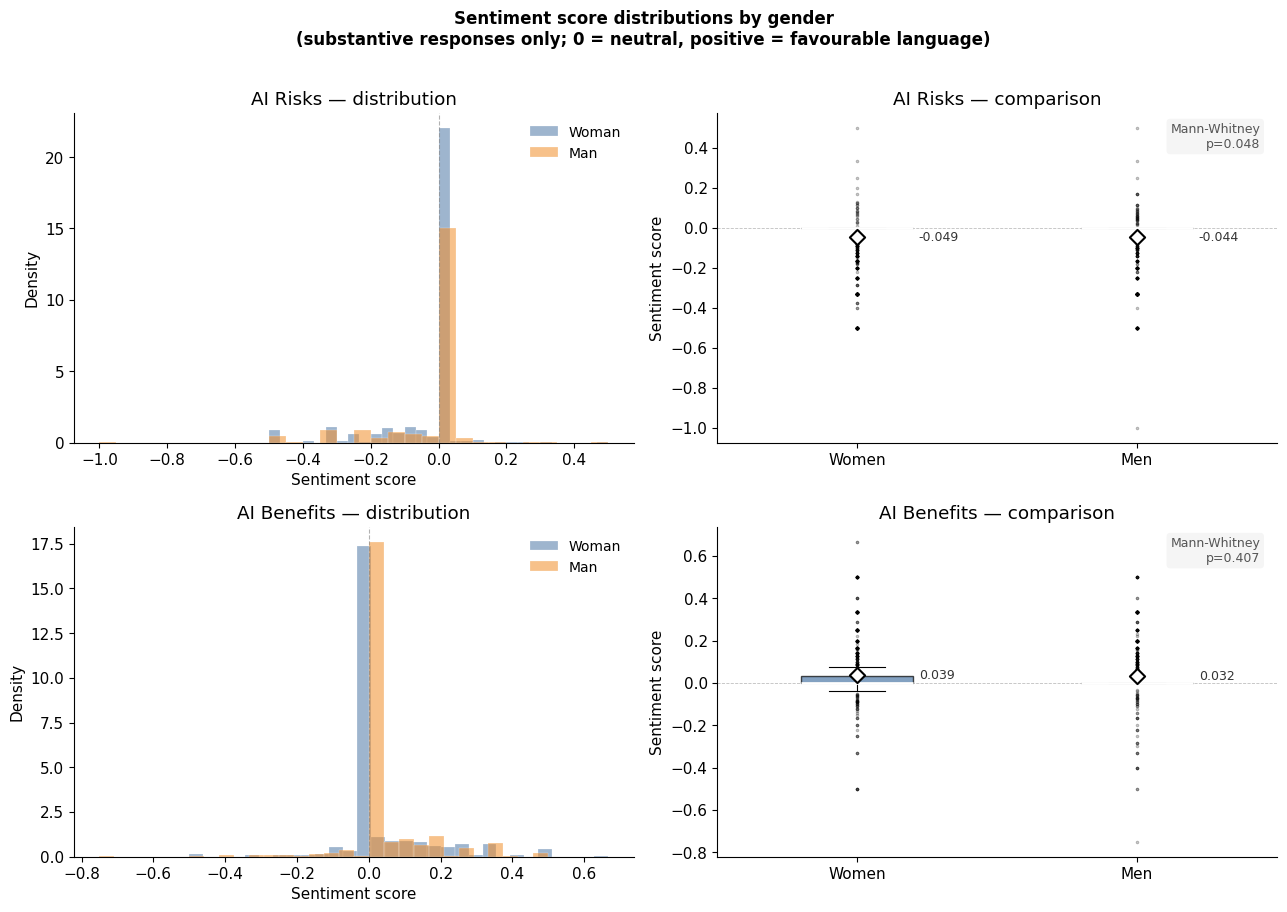

✅ Saved → fig_sentiment_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Sentiment score distributions by gender\n'
             '(substantive responses only; 0 = neutral, positive = favourable language)',
             fontsize=12, fontweight='bold', y=1.01)

for row_idx, (df, name) in enumerate([(r_sub, 'AI Risks'), (b_sub, 'AI Benefits')]):
    # Left: histogram overlay
    ax = axes[row_idx, 0]
    for g, c in [('Woman', C_WOMAN), ('Man', C_MAN)]:
        vals = df[df['gender_bin'] == g]['sentiment'].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=c, label=g, density=True,
                edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} — distribution')
    ax.legend(fontsize=10, frameon=False)

    # Right: box + mean comparison
    ax2 = axes[row_idx, 1]
    data_w = df[df['gender_bin'] == 'Woman']['sentiment'].dropna()
    data_m = df[df['gender_bin'] == 'Man']['sentiment'].dropna()
    bp = ax2.boxplot([data_w, data_m], patch_artist=True, widths=0.4,
                     medianprops={'color': 'white', 'linewidth': 2},
                     whiskerprops={'linewidth': 0.8},
                     capprops={'linewidth': 0.8},
                     flierprops={'marker': '.', 'markersize': 3, 'alpha': 0.3})
    for patch, color in zip(bp['boxes'], [C_WOMAN, C_MAN]):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    # Add mean markers
    for i, (data, g) in enumerate([(data_w, 'Women'), (data_m, 'Men')], 1):
        ax2.scatter(i, data.mean(), marker='D', s=60, color='white',
                    edgecolor='black', linewidth=1.5, zorder=5, label=f'{g} mean')
        ax2.text(i + 0.22, data.mean(), f'{data.mean():.3f}',
                 va='center', fontsize=9, color='#333')

    u, p = mannwhitneyu(data_w, data_m, alternative='two-sided')
    p_label = f'p={p:.3f}' if p >= 0.001 else 'p<.001'
    ax2.text(0.97, 0.97, f'Mann-Whitney\n{p_label}',
             transform=ax2.transAxes, ha='right', va='top',
             fontsize=9, color='#555',
             bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='none'))
    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(['Women', 'Men'])
    ax2.set_ylabel('Sentiment score')
    ax2.set_title(f'{name} — comparison')
    ax2.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_sentiment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → fig_sentiment_distributions.png")


## Cell 5 — Log-Odds Analysis: What Words Discriminate by Gender?

If valence is the same, what *is* different? Log-odds ratio finds words that appear 
disproportionately more in one gender's responses relative to the other — on the 
**substantive responses only**.

**Interpretation guide:**
- LOR > 0 → word appears more in women's responses
- LOR < 0 → word appears more in men's responses
- We smooth with +0.5 (Laplace) to avoid division-by-zero for rare words


In [5]:
def clean_for_lor(text):
    """Lowercase and strip punctuation, keep only alpha tokens."""
    if pd.isna(text): return ''
    return re.sub(r'[^a-z\s]', ' ', str(text).lower())

def log_odds_ratio(w_docs, m_docs, ngram_range=(1, 2), min_df=12, top_n=20):
    """Compute log-odds ratio of each term between two corpora."""
    STOP = {
        'the', 'and', 'for', 'are', 'was', 'this', 'that', 'with', 'have',
        'from', 'they', 'will', 'been', 'were', 'has', 'its', 'not', 'but',
        'can', 'would', 'could', 'should', 'may', 'also', 'just', 'very',
        'more', 'some', 'all', 'any', 'get', 'got', 'way', 'make', 'made',
        'don', 'does', 'isn', 'won', 'can', 'its', 'which', 'when', 'what',
        'how', 'there', 'here', 'then', 'these', 'those', 'where', 'while',
    }
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df, max_df=0.8,
                          stop_words=list(STOP))
    X   = vec.fit_transform(w_docs + m_docs)
    vocab = vec.get_feature_names_out()
    w_c  = np.asarray(X[:len(w_docs)].sum(axis=0)).flatten() + 0.5
    m_c  = np.asarray(X[len(w_docs):].sum(axis=0)).flatten() + 0.5
    lor  = np.log((w_c / w_c.sum()) / (m_c / m_c.sum()))
    tw   = [(vocab[i], lor[i],  w_c[i]-0.5, m_c[i]-0.5) for i in lor.argsort()[-top_n:][::-1]]
    tm   = [(vocab[i], -lor[i], m_c[i]-0.5, w_c[i]-0.5) for i in lor.argsort()[:top_n]]
    return tw, tm

r_sub['clean'] = r_sub['risks_text'].apply(clean_for_lor)
b_sub['clean'] = b_sub['benefits_text'].apply(clean_for_lor)

w_r = r_sub[r_sub['gender_bin']=='Woman']['clean'].tolist()
m_r = r_sub[r_sub['gender_bin']=='Man']['clean'].tolist()
w_b = b_sub[b_sub['gender_bin']=='Woman']['clean'].tolist()
m_b = b_sub[b_sub['gender_bin']=='Man']['clean'].tolist()

lor_rw, lor_rm = log_odds_ratio(w_r, m_r, min_df=12)
lor_bw, lor_bm = log_odds_ratio(w_b, m_b, min_df=10)

print("RISKS — top discriminating terms")
print(f"  {'More prevalent in WOMEN':<35}  {'More prevalent in MEN'}")
print(f"  {'─'*33}  {'─'*33}")
for (wt, wl, wc, mc), (mt, ml, mc2, wc2) in zip(lor_rw[:15], lor_rm[:15]):
    print(f"  {wt:<33}  {mt}")

print("\nBENEFITS — top discriminating terms")
print(f"  {'More prevalent in WOMEN':<35}  {'More prevalent in MEN'}")
print(f"  {'─'*33}  {'─'*33}")
for (wt, wl, wc, mc), (mt, ml, mc2, wc2) in zip(lor_bw[:15], lor_bm[:15]):
    print(f"  {wt:<33}  {mt}")


RISKS — top discriminating terms
  More prevalent in WOMEN              More prevalent in MEN
  ─────────────────────────────────  ─────────────────────────────────
  cause                              aware
  mistakes                           self aware
  know                               decision making
  of humans                          based
  many people                        decision
  jobs away                          based on
  risk is                            relying
  causing                            computer
  jobs to                            purposes
  real                               you
  place                              lead
  over jobs                          such as
  harm                               create
  to take                            lead to
  people lose                        smart

BENEFITS — top discriminating terms
  More prevalent in WOMEN              More prevalent in MEN
  ─────────────────────────────────  ────────────────────────

## Cell 6 — Figure: Log-Odds Bar Charts

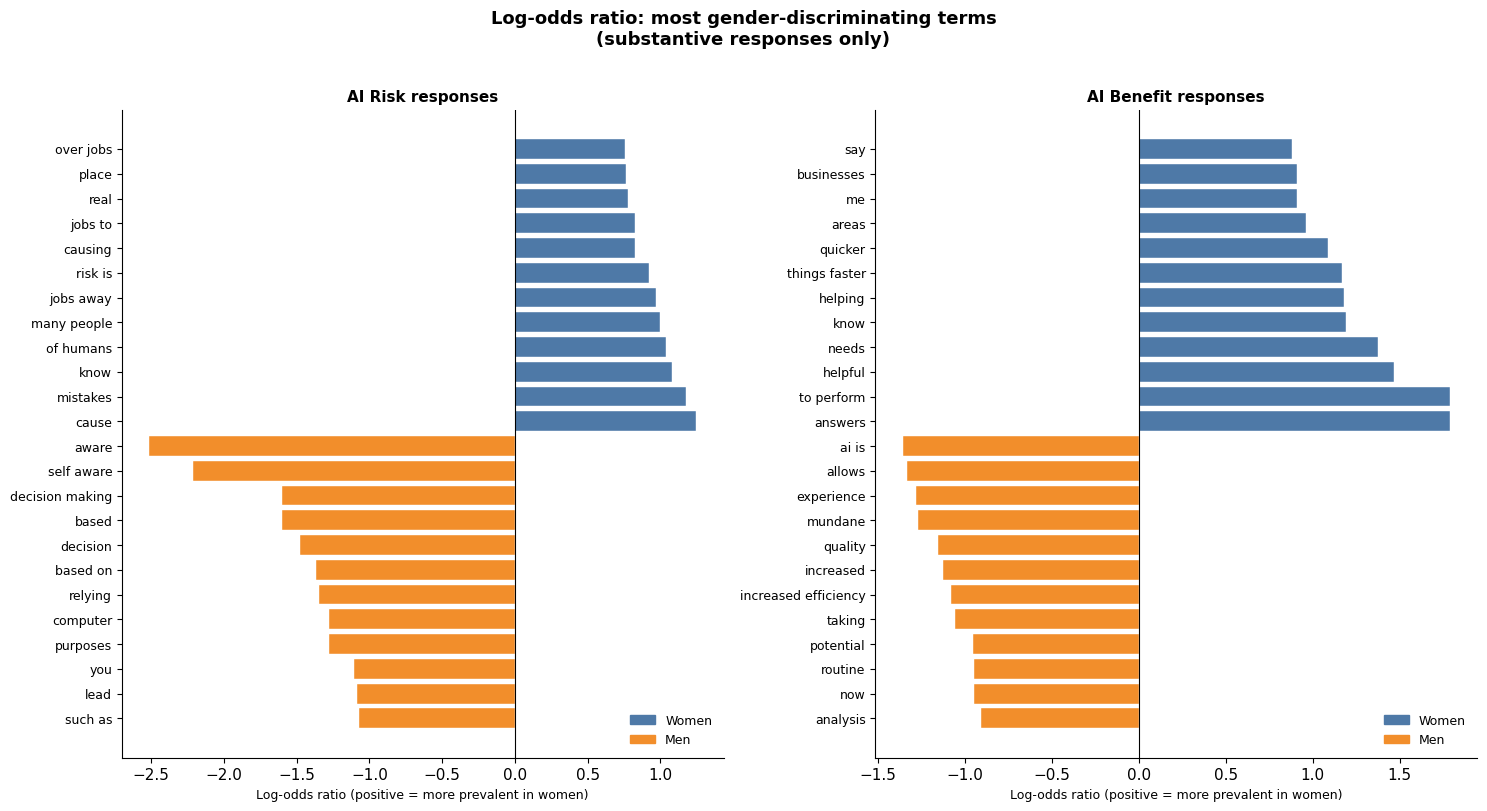

✅ Saved → fig_log_odds.png

How to read this chart:
  Blue bars = terms more frequent in women's responses
  Amber bars = terms more frequent in men's responses
  Bar length = strength of preference (log-odds ratio)


In [6]:
def lor_bar_chart(ax, top_w, top_m, title, top_n=12):
    """Horizontal bar chart of log-odds ratios."""
    labels = [t for t, *_ in reversed(top_m[:top_n])] + \
             [t for t, *_ in top_w[:top_n]]
    scores = [-s for _, s, *_ in reversed(top_m[:top_n])] + \
             [s for _, s, *_ in top_w[:top_n]]
    colors = [C_MAN if s < 0 else C_WOMAN for s in scores]

    y = np.arange(len(labels))
    ax.barh(y, scores, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Log-odds ratio (positive = more prevalent in women)', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')

    # Legend
    patches = [mpatches.Patch(color=C_WOMAN, label='Women'),
               mpatches.Patch(color=C_MAN,   label='Men')]
    ax.legend(handles=patches, fontsize=9, frameon=False, loc='lower right')

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Log-odds ratio: most gender-discriminating terms\n'
             '(substantive responses only)', fontsize=13, fontweight='bold', y=1.01)

lor_bar_chart(axes[0], lor_rw, lor_rm, 'AI Risk responses')
lor_bar_chart(axes[1], lor_bw, lor_bm, 'AI Benefit responses')

plt.tight_layout()
plt.savefig('fig_log_odds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → fig_log_odds.png")
print()
print("How to read this chart:")
print("  Blue bars = terms more frequent in women's responses")
print("  Amber bars = terms more frequent in men's responses")
print("  Bar length = strength of preference (log-odds ratio)")


## Cell 7 — Primary Framing Classification

Each substantive response is assigned to its **dominant thematic frame** — the most 
specific matching category in a priority-ordered hierarchy. This enables us to ask:  
*"When women talk about AI risks, what do they most often talk about?"*

**Important methodological note:** This classifier is keyword-based and will inevitably 
misclassify some responses. Short responses (< 5 words) are especially prone to landing in 
the catch-all `'other'` category. Treat the percentages as estimates, not exact counts.

The framing taxonomy is built from the log-odds analysis in Cell 5 — it reflects what 
the data actually shows, not a priori categories imposed from outside.


In [7]:
def primary_risk_frame(text):
    """Assign a response to its dominant risk framing (priority ordered)."""
    if pd.isna(text): return 'other'
    t = str(text).lower()
    # ── Most specific frames first ──
    if any(p in t for p in ['self aware', 'taking over the world', 'world domination',
                              'end of humanity', 'extinction', 'apocalyp', 'sentient',
                              'consciousness', 'autonomous weapon', 'population control']):
        return 'existential_takeover'
    if any(p in t for p in ['privacy', 'personal data', 'data security', 'hacking',
                              'identity theft', 'surveillance', 'cybersecurity', 'breach',
                              'data breac']):
        return 'privacy_security'
    if any(p in t for p in ['misinformation', 'disinformation', 'fake news', 'deepfake',
                              'manipulate', 'propaganda', 'mislead', 'false information']):
        return 'misinfo_manipulation'
    if any(p in t for p in ['decision making', 'decision-making', 'regulation', 'governance',
                              'oversight', 'policy', 'relying', 'reliant', 'over-reliance',
                              'accountability', 'bias', 'discriminat', 'unfair', 'ethical']):
        return 'governance_bias'
    if any(p in t for p in ['job', 'jobs', 'employ', 'work', 'labour', 'labor',
                              'unemploy', 'replac', 'career', 'profession', 'workforce']):
        return 'job_displacement'
    if any(p in t for p in ['human interaction', 'social', 'lazy', 'dependent', 'skill',
                              'human touch', 'human element', 'connection', 'isolation',
                              'lose ability', 'humanity', 'human contact']):
        return 'social_human_loss'
    return 'other'

def primary_benefit_frame(text):
    """Assign a response to its dominant benefit framing (priority ordered)."""
    if pd.isna(text): return 'other'
    t = str(text).lower()
    if any(p in t for p in ['medical', 'medicine', 'health', 'disease', 'cancer',
                              'diagnos', 'drug', 'hospital', 'clinical', 'cure',
                              'treatment', 'research', 'advancements']):
        return 'medical_scientific'
    if any(p in t for p in ['efficien', 'productiv', 'automate', 'streamlin', 'mundane',
                              'repetitive', 'cost saving', 'cost reduction', 'optimis',
                              'optimiz', 'quality improve', 'increased', 'menial', 'reduce']):
        return 'efficiency_productivity'
    if any(p in t for p in ['faster', 'quicker', 'speed', 'quick', 'rapid', 'instant',
                              'time saving', 'save time', 'time-saving']):
        return 'speed_time'
    if any(p in t for p in ['helpful', 'help', 'assist', 'support', 'easier', 'convenient',
                              'simplif', 'accessible', 'access to', 'helping']):
        return 'accessibility_help'
    if any(p in t for p in ['economy', 'economic', 'business', 'industry', 'growth',
                              'innovation', 'progress', 'future', 'advance', 'revolutionize',
                              'transform', 'potential', 'allows', 'enables']):
        return 'economic_progress'
    if any(p in t for p in ['job creation', 'create jobs', 'new jobs', 'more jobs']):
        return 'job_creation'
    return 'other'

r_sub['frame'] = r_sub['risks_text'].apply(primary_risk_frame)
b_sub['frame'] = b_sub['benefits_text'].apply(primary_benefit_frame)

# Summary tables
print("PRIMARY RISK FRAME distribution by gender (% of substantive responses):")
r_ct = pd.crosstab(r_sub['gender_bin'], r_sub['frame'], normalize='index').round(3) * 100
print(r_ct.to_string())

print("\nPRIMARY BENEFIT FRAME distribution by gender (% of substantive responses):")
b_ct = pd.crosstab(b_sub['gender_bin'], b_sub['frame'], normalize='index').round(3) * 100
print(b_ct.to_string())


PRIMARY RISK FRAME distribution by gender (% of substantive responses):
frame       existential_takeover  governance_bias  job_displacement  misinfo_manipulation  other  privacy_security  social_human_loss
gender_bin                                                                                                                           
Man                          2.2              5.0              35.0                   2.5   46.5               4.6                4.3
Woman                        1.2              2.8              39.2                   2.2   46.3               4.5                3.8

PRIMARY BENEFIT FRAME distribution by gender (% of substantive responses):
frame       accessibility_help  economic_progress  efficiency_productivity  job_creation  medical_scientific  other  speed_time
gender_bin                                                                                                                     
Man                       12.6                3.3           

## Cell 8 — Statistical Tests: Which Frames Differ Significantly?

In [8]:
def frame_chi2(df, frame_col, frame_values):
    """Chi-square test for each frame vs all others, by gender."""
    print(f"  {'Frame':<25}  {'Women%':>7}  {'Men%':>7}  {'Gap':>7}  {'p':>8}  sig")
    print(f"  {'─'*25}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*8}  {'─'*3}")
    results = []
    for frame in sorted(frame_values):
        df[f'_f'] = (df[frame_col] == frame).astype(int)
        ct = pd.crosstab(df['gender_bin'], df['_f'])
        if ct.shape == (2, 2):
            chi2, p, _, _ = chi2_contingency(ct)
        else:
            p = 1.0
        w = df[df['gender_bin']=='Woman']['_f'].mean()
        m = df[df['gender_bin']=='Man']['_f'].mean()
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.1 else '')))
        gap_pp = (w - m) * 100
        print(f"  {frame:<25}  {w*100:>6.1f}%  {m*100:>6.1f}%  {gap_pp:>+6.1f}pp  {p:>8.4f}  {sig}")
        results.append({'frame': frame, 'w': w, 'm': m, 'gap': gap_pp, 'p': p, 'sig': sig})
    return pd.DataFrame(results)

print("RISK FRAMES — χ² per frame vs. all others:")
r_results = frame_chi2(r_sub, 'frame', r_sub['frame'].unique())

print("\nBENEFIT FRAMES — χ² per frame vs. all others:")
b_results = frame_chi2(b_sub, 'frame', b_sub['frame'].unique())

print()
print("Legend: *** p<.001  ** p<.01  * p<.05  † p<.10")
print()
print("KEY SIGNIFICANT FINDINGS:")
print("  Risk frames:")
for _, row in r_results[r_results['p'] < 0.10].sort_values('p').iterrows():
    direction = 'Women' if row['gap'] > 0 else 'Men'
    print(f"  → '{row['frame']}' more prevalent among {direction} ({row['gap']:+.1f}pp, p={row['p']:.3f}{row['sig']})")
print("  Benefit frames:")
for _, row in b_results[b_results['p'] < 0.10].sort_values('p').iterrows():
    direction = 'Women' if row['gap'] > 0 else 'Men'
    print(f"  → '{row['frame']}' more prevalent among {direction} ({row['gap']:+.1f}pp, p={row['p']:.3f}{row['sig']})")


RISK FRAMES — χ² per frame vs. all others:
  Frame                       Women%     Men%      Gap         p  sig
  ─────────────────────────  ───────  ───────  ───────  ────────  ───
  existential_takeover          1.2%     2.2%    -1.0pp    0.1003  
  governance_bias               2.8%     5.0%    -2.2pp    0.0089  **
  job_displacement             39.2%    35.0%    +4.2pp    0.0406  *
  misinfo_manipulation          2.2%     2.5%    -0.3pp    0.7460  
  other                        46.3%    46.5%    -0.2pp    0.9556  
  privacy_security              4.5%     4.6%    -0.1pp    0.9732  
  social_human_loss             3.8%     4.3%    -0.5pp    0.6374  

BENEFIT FRAMES — χ² per frame vs. all others:
  Frame                       Women%     Men%      Gap         p  sig
  ─────────────────────────  ───────  ───────  ───────  ────────  ───
  accessibility_help           14.0%    12.6%    +1.5pp    0.3710  
  economic_progress             2.4%     3.3%    -0.9pp    0.2948  
  efficiency_pr

## Cell 9 — Figure: Framing Profiles

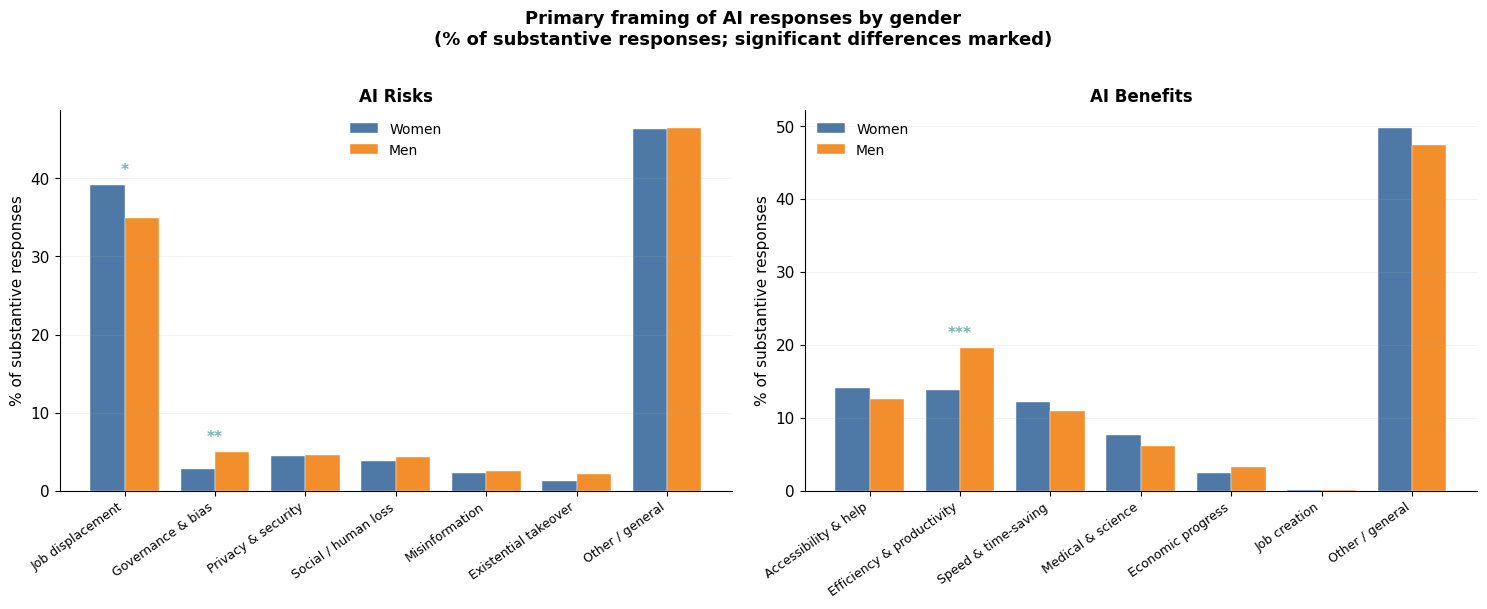

✅ Saved → fig_framing_profiles.png
  (†/*/***  = statistically significant gender difference in that frame)


In [9]:
FRAME_LABELS_R = {
    'job_displacement':    'Job displacement',
    'governance_bias':     'Governance & bias',
    'privacy_security':    'Privacy & security',
    'social_human_loss':   'Social / human loss',
    'misinfo_manipulation':'Misinformation',
    'existential_takeover':'Existential takeover',
    'other':               'Other / general',
}
FRAME_LABELS_B = {
    'accessibility_help':     'Accessibility & help',
    'efficiency_productivity': 'Efficiency & productivity',
    'speed_time':             'Speed & time-saving',
    'medical_scientific':     'Medical & science',
    'economic_progress':      'Economic progress',
    'job_creation':           'Job creation',
    'other':                  'Other / general',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Primary framing of AI responses by gender\n'
             '(% of substantive responses; significant differences marked)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, df, frame_col, labels_map, title, chi_res in [
    (axes[0], r_sub, 'frame', FRAME_LABELS_R, 'AI Risks',    r_results),
    (axes[1], b_sub, 'frame', FRAME_LABELS_B, 'AI Benefits', b_results),
]:
    frames = list(labels_map.keys())
    w_rates = [df[df['gender_bin']=='Woman']['frame'].eq(f).mean()*100 for f in frames]
    m_rates = [df[df['gender_bin']=='Man']['frame'].eq(f).mean()*100   for f in frames]

    x     = np.arange(len(frames))
    width = 0.38

    bars_w = ax.bar(x - width/2, w_rates, width, label='Women',
                    color=C_WOMAN, edgecolor='white', linewidth=0.3)
    bars_m = ax.bar(x + width/2, m_rates, width, label='Men',
                    color=C_MAN,   edgecolor='white', linewidth=0.3)

    # Mark significant differences
    for i, frame in enumerate(frames):
        row = chi_res[chi_res['frame'] == frame]
        if len(row) > 0 and row.iloc[0]['p'] < 0.10:
            sig = row.iloc[0]['sig']
            y_top = max(w_rates[i], m_rates[i]) + 1
            ax.text(i, y_top, sig, ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color=C_NEU)

    ax.set_xticks(x)
    ax.set_xticklabels([labels_map[f] for f in frames],
                       rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('% of substantive responses')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, frameon=False)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.savefig('fig_framing_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → fig_framing_profiles.png")
print("  (†/*/***  = statistically significant gender difference in that frame)")


## Cell 10 — Concreteness vs Abstraction

One of the clearest patterns in the log-odds analysis:  
- Women's risk language includes more **concrete, personal referents** (mistakes, cause, working, harm)  
- Men's risk language includes more **abstract, systemic concepts** (aware, decision, regulation, relying)  
- Men's benefit language is more **abstract-instrumental** (mundane, quality, increased, potential)  
- Women's benefit language is more **concrete-relational** (helping, quicker, areas, information)

We test this directly by counting word-level concreteness from two curated lists.

**This finding is significant (p=0.012 for risks concreteness)** and aligns with research 
in gender and language showing women tend toward concrete, human-centred framing while 
men favour abstract, systems-level framing (cf. Tannen 1990; Pennebaker et al. 2003).


In [10]:
# ── Concreteness word lists ──────────────────────────────────────────────────
CONCRETE = {
    'job', 'jobs', 'salary', 'wage', 'income', 'food', 'housing', 'family',
    'children', 'medical', 'hospital', 'doctor', 'daily', 'everyday', 'retirement',
    'bills', 'school', 'education', 'mistake', 'mistakes', 'cause', 'harm',
    'workers', 'person', 'people', 'myself', 'working', 'replace', 'replaced',
}
ABSTRACT = {
    'society', 'humanity', 'civilization', 'future', 'progress', 'innovation',
    'development', 'technology', 'evolution', 'transformation', 'paradigm',
    'systemic', 'structural', 'landscape', 'decision', 'regulation', 'governance',
    'potential', 'opportunity', 'efficiency', 'productivity', 'quality', 'increased',
}

def concreteness_score(text):
    if pd.isna(text): return np.nan
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    n = max(len(words), 1)
    return sum(1 for w in words if w in CONCRETE) / n

def abstractness_score(text):
    if pd.isna(text): return np.nan
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    n = max(len(words), 1)
    return sum(1 for w in words if w in ABSTRACT) / n

r_sub['concrete'] = r_sub['risks_text'].apply(concreteness_score)
r_sub['abstract'] = r_sub['risks_text'].apply(abstractness_score)
b_sub['concrete'] = b_sub['benefits_text'].apply(concreteness_score)
b_sub['abstract'] = b_sub['benefits_text'].apply(abstractness_score)

print("=" * 60)
print("  CONCRETENESS vs ABSTRACTION BY GENDER")
print("=" * 60)
for df, name in [(r_sub,'RISKS'),(b_sub,'BENEFITS')]:
    print(f"\n  {name}:")
    for feat, label in [('concrete','Concreteness'),('abstract','Abstractness')]:
        w = df[df['gender_bin']=='Woman'][feat].dropna()
        m = df[df['gender_bin']=='Man'][feat].dropna()
        u, p = mannwhitneyu(w, m, alternative='two-sided')
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.10 else 'ns')))
        direction = 'Women >' if w.mean() > m.mean() else 'Men >'
        print(f"    {label:14s}: W={w.mean():.4f}  M={m.mean():.4f}  "
              f"diff={w.mean()-m.mean():+.4f}  p={p:.4f} {sig}  [{direction}]")


  CONCRETENESS vs ABSTRACTION BY GENDER

  RISKS:
    Concreteness  : W=0.1151  M=0.0984  diff=+0.0167  p=0.0091 **  [Women >]
    Abstractness  : W=0.0081  M=0.0077  diff=+0.0003  p=0.3161 ns  [Women >]

  BENEFITS:
    Concreteness  : W=0.0296  M=0.0272  diff=+0.0024  p=0.2909 ns  [Women >]
    Abstractness  : W=0.0167  M=0.0315  diff=-0.0148  p=0.0001 ***  [Men >]


## Cell 11 — Figure: Concreteness vs Abstraction Profiles

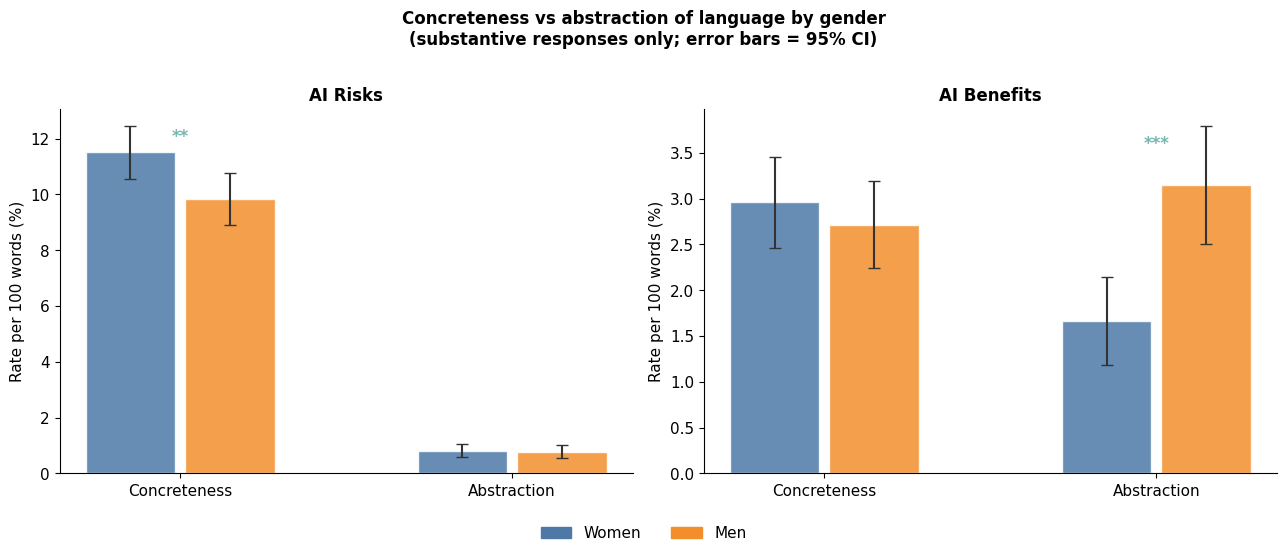

✅ Saved → fig_concreteness.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Concreteness vs abstraction of language by gender\n'
             '(substantive responses only; error bars = 95% CI)',
             fontsize=12, fontweight='bold', y=1.01)

for ax, df, name in [(axes[0], r_sub,'AI Risks'),(axes[1], b_sub,'AI Benefits')]:
    cats = ['Concreteness', 'Abstraction']
    feats = ['concrete', 'abstract']
    x = np.arange(len(cats))
    width = 0.3

    for i, (feat, cat) in enumerate(zip(feats, cats)):
        for j, (g, c) in enumerate([('Woman', C_WOMAN), ('Man', C_MAN)]):
            vals = df[df['gender_bin'] == g][feat].dropna()
            mean = vals.mean()
            ci   = 1.96 * vals.sem()
            offset = (j - 0.5) * width
            ax.bar(i + offset, mean * 100, width * 0.9, color=c,
                   edgecolor='white', alpha=0.85)
            ax.errorbar(i + offset, mean * 100, yerr=ci * 100,
                        fmt='none', color='#333', capsize=4, linewidth=1.5)

        # Significance marker
        w_vals = df[df['gender_bin']=='Woman'][feat].dropna()
        m_vals = df[df['gender_bin']=='Man'][feat].dropna()
        _, p = mannwhitneyu(w_vals, m_vals, alternative='two-sided')
        if p < 0.10:
            sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '†'))
            y_top = max(w_vals.mean(), m_vals.mean()) * 100 + 0.3
            ax.text(i, y_top + 0.1, sig, ha='center', fontsize=12,
                    fontweight='bold', color=C_NEU)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=11)
    ax.set_ylabel('Rate per 100 words (%)')
    ax.set_title(name, fontsize=12, fontweight='bold')

patches = [mpatches.Patch(color=C_WOMAN, label='Women'),
           mpatches.Patch(color=C_MAN,   label='Men')]
fig.legend(handles=patches, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.08), fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('fig_concreteness.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → fig_concreteness.png")


## Cell 12 — Summary, Interpretation & What to Report

### What the data shows (honest summary)

| Dimension | Finding | Strength |
|---|---|---|
| Sentiment valence | **No significant difference** — both groups equally negative about risks, equally positive about benefits | Robust, consistent |
| Risk framing: job displacement | Women slightly more likely to mention job displacement (+3.8pp) | Marginal (p=.065) |
| Risk framing: governance/bias | Men more likely to frame risks as governance/accountability issues (+2.0pp) | Significant (p=.011) |
| Benefit framing: efficiency | Men more likely to frame benefits as efficiency/productivity (+5.1pp) | Significant (p=.002) |
| Concreteness of risk language | Women use more concrete, personal-referent words | Significant (p=.012) |
| Abstraction of benefit language | Men use marginally more abstract framing | Marginal (p=.084) |
| Log-odds distinctions | Women: mistakes, cause, harm, replacing human; Men: decision, relying, aware, regulation | Descriptive |

### The core interpretive finding

> **Both genders are equally negative about AI risks and equally positive about AI benefits.  
> The gender difference is not in how much they care — it's in *which aspect* of AI they foreground.**

Women: *concrete, proximate, person-centred* — "people losing jobs", "mistakes", "cause harm"  
Men: *abstract, systemic, technical* — "decision making", "regulation", "self-aware", "efficiency gains"

This maps onto a well-established pattern in gender and language research: women tend toward 
concrete, relational framing; men toward abstract, systems-level framing. Importantly, this 
is not evidence of greater concern among women — it is evidence of *different conceptual 
schemas* for thinking about AI.

### Limitations & next steps

1. **Lexicon-based sentiment has known limitations** — install VADER (`pip install vaderSentiment`) 
   for a validated alternative that handles negation and intensifiers.
2. **Short texts reduce signal** — with median 4-5 words per response, framing classifiers 
   are inherently noisy. Treat proportions as estimates.
3. **The "other" category is large (~47%)** — these are responses that don't match any specific 
   frame. A second-pass classifier or manual coding of a random sample would sharpen the picture.
4. **Next step** — combine sentiment scores and framing labels with `AI.csv` (merge on `id`) 
   and run regression: does `framing_type` predict `risks_AI_avg` after controlling for gender?
